##### Intro to Python Programming
- Prof Joanna Bieri
- Office: Duke 209


### Day 16 - Functions Continued


#### Basic Function Format

     def function_name(parameter1, parameter2,...):
         ''' Comments about the function '''
         code
         code
         code
         
         return value
         
#### Parameter Types.

You often want to combine different parameter types in a function. You should be careful of order here:

- FIRST you should define positional arguments - these are parameters that just have a name.
- SECOND you should define keyword arguments - these are parameters that just have a name in the function, but you send them in as keword=value.
- THIRD you should define arbitrary arguments - these are parameters that have a * as can accept an unknown number of unputs.
- FOURTH you should define all default arguments - these are parameters that have a given value param1=False, param2=' '.

### Styling Functions - Good Habits.

- Functions should have descriptive names using lowercase letters and underscores.
- Functions should have comments at the top using '''  ''' that explains concisely what the function does. This comment should allow other users to use the function by just reading the comment.
- Remove spaces around default and keyword arguments in the function definition.
- Separate functions by two blank lines so it is easy to see were one function ends and the next begins.
- All imports should be at the beginning of a file just after any comments
- After imports you should define global variables
- Then define your functions
- Last is your main code.

#### Here is some code that is poorly styled. Let's fix it together.

There are 102449 names in the data frame.


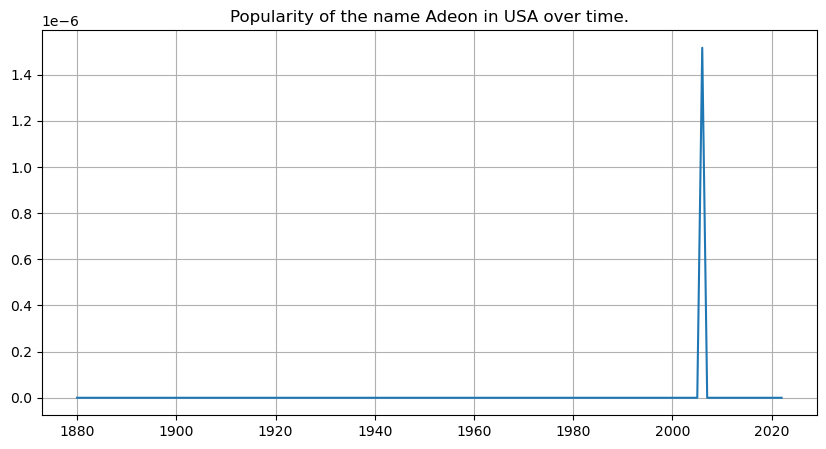

In [1]:
def function1(names):
    import numpy as np
    num = np.random.randint(len(names))
    return names[num]

    

file_name = 'names_by_birth_year.csv'
website = 'https://joannabieri.com/python/'
import pandas as pd
DF = pd.read_csv(website+file_name)
years_covered = list(DF['Year'].unique())


def function2(DF):
    names_listed = list(DF['Name'].unique())
    num_names = len(names_listed)
    print(f'There are {num_names} names in the data frame.')
    return names_listed
import matplotlib.pyplot as plt
def function3(DF,my_name,years_covered,birth_info):
    my_name_info = {}
    for year in sorted(years_covered):
        mask_year = DF['Year']==year
        DF_year = DF[mask_year]
        name_mask = DF_year['Name']==my_name
        DF_year_name = DF_year[name_mask]
        num_people = sum(DF_year_name['Count'])/birth_info[year]
        #print(f'In {year}, {num_people} percent of the recorded people were named {my_name}.')
        my_name_info[year]=num_people
    plt.figure(figsize=(10,5))
    x_data = my_name_info.keys()
    y_data = my_name_info.values()
    plt.plot(x_data,y_data)
    plt.title(f'Popularity of the name {my_name} in USA over time.')
    plt.grid()
    plt.show()
    
def function4(years_covered):
    birth_info = {}

    for year in sorted(years_covered):
        mask_year = DF['Year']==year
        DF_year = DF[mask_year]
        num_people = DF_year['Count'].sum()
        birth_info[year]=num_people
    return birth_info
    

nlist = function2(DF)
n = function1(nlist)
binfo = function4(years_covered)
function3(DF,n,years_covered,binfo)

In [ ]:
# Here is the code properly styled

There are 102449 names in the data frame.


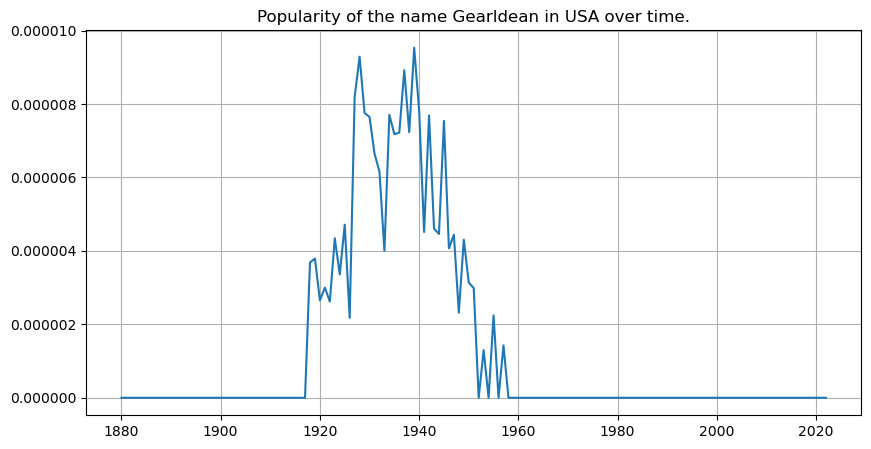

In [2]:
# Plot a random names popularity over time
# by Joanna Bieri
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import birth names data
file_name = 'names_by_birth_year.csv'
website = 'https://joannabieri.com/python/'
DF = pd.read_csv(website+file_name)

# Functions
def get_one_name(names):
    '''Given a list of names returns a random name'''
    num = np.random.randint(len(names))
    return names[num]

    
def unique_names(DF):
    '''Given a Data Frame with a column ('Name') 
    returns the unique names in the column.
    Expects data from: names_by_birth_year.csv
    '''
    names_listed = list(DF['Name'].unique())
    num_names = len(names_listed)
    print(f'There are {num_names} names in the data frame.')
    return names_listed
        

def get_num_born(DF, years_covered):
    '''Given a data frame with the columns ('Year','Count')
    calculates the number of people born over that year.
    Expects data from: names_by_birth_year.csv'''
    birth_info = {}
    for year in sorted(years_covered):
        mask_year = DF['Year']==year
        DF_year = DF[mask_year]
        num_people = DF_year['Count'].sum()
        birth_info[year]=num_people
    return birth_info


def plot_name_popularity(DF,my_name):
    ''' Given a data fram that contains columns ('Year','Name')
    and a single name, plots the names popularity over time.
    Expects data from: names_by_birth_year.csv'''
    # Get the range of years
    years_covered = list(DF['Year'].unique())
    # Get the numbers born
    birth_info = get_num_born(DF, years_covered)  
    # Get the data for my_name
    my_name_info = {}
    for year in sorted(years_covered):
        mask_year = DF['Year']==year
        DF_year = DF[mask_year]
        name_mask = DF_year['Name']==my_name
        DF_year_name = DF_year[name_mask]
        num_people = sum(DF_year_name['Count'])/birth_info[year]
        my_name_info[year]=num_people     
    # Plot
    plt.figure(figsize=(10,5))
    x_data = my_name_info.keys()
    y_data = my_name_info.values()
    plt.plot(x_data,y_data)
    plt.title(f'Popularity of the name {my_name} in USA over time.')
    plt.grid()
    plt.ticklabel_format(style='plain')
    plt.show()
    

# Main Code

# Get the name to plot
name_list = unique_names(DF)
single_name = get_one_name(nlist)
# Plot the name
plot_name_popularity(DF,single_name)

## A really helpful command:

### Try - Except

When you are dealing with user inputs, it is hard to anticipate what the user might enter. Lets say that you are expecting a number but the user enters a string. This will cause an error in your code! The Try-Except statement lets you test this. 

In [3]:
def add_two_numbers(a,b):
    '''Adds a+b'''
    print(a+b)


# Main Code
a = float(input('Enter a number: '))
b = float(input('Enter another number: '))

add_two_numbers(a,b)

Enter a number:  5
Enter another number:  4


9.0


In [4]:
def add_two_numbers(a,b):
    '''Adds a+b'''
    print(a+b)


# Main Code
ans1 = input('Enter a number: ')
ans2 = input('Enter another number: ')

try:
    a = float(ans1)
    b = float(ans2)
    add_two_numbers(a,b)
except:
    print('Both entries must be numbers!')

Enter a number:  4
Enter another number:  4


8.0


### Practice Problems

For each of the practice problems below. Write clean and properly styled code. If you find your code needs a lot of functions you may put your functions into a module (your choice).


#### Practice 1 - Multiplication Tables

Write a function that inputs a number and prints the multiplication table of that number.

eg. Given the number 9 it should print:

    9 * 1 = 9
    9 * 2 = 18
    9 * 3 = 27
    9 * 4 = 36
    9 * 5 = 45
    9 * 6 = 54
    9 * 7 = 63
    9 * 8 = 72
    9 * 9 = 81
    9 * 10 = 90

In [11]:
# Your code here
def mult_table(n):
    for i in range(1, 11):
        print(n * i)
mult_table(9)

9
18
27
36
45
54
63
72
81
90


#### Practice 2 - Finbonacci Numbers

Write a program that asks the user how many Fibonnaci numbers to generate and then generates them. The Fibonnaci seqence is a sequence of numbers where the next number in the sequence is the sum of the previous two numbers in the sequence. The sequence always starts with 1,1 but then then next number is 1+1=2 and the next number is 1+2=3. So the sequence looks like: 1, 1, 2, 3, 5, 8, 13, …

- The main part of the function should include the user input information
- You should write a function that takes as an input how many numbers the user wants and returns the list of numbers.
- Finally print the result

In [12]:
# Your code here
def fibonacci(n):
    nums = [1, 1]
    while len(nums) < n:
        nums.append(nums[-1] + nums[-2])
    return nums[:n]

n = int(input("How many Fibonacci numbers? "))
print(fibonacci(n))

How many Fibonacci numbers?  4


[1, 1, 2, 3]


#### Practice 3 - Secret Messages

Write two functions:

1. The first function should be an ENCODER. It should take as an input a string and return that string after a serise of operations has been done. You can come up with any set of operations you want! As a frist try you could just flip the string backward.

2. The second function should be the DECODER. It should undo what evern operations the ENCODER did. So if your encoder turned the string backward then the decoder should return it to the proper direction.

eg. 

            message = 'hello world'
            e_message = encoder(message)

- e_message (encoded message) will contain the string 'dlrow olleh'

           o_message = decoder(e_message)

- o_message (original message) will contain the string 'hello world'

In [13]:
# Your code here:
def encoder(message):
    return message[::-1]

def decoder(message):
    return message[::-1]

message = "hello world"
e_message = encoder(message)
print(e_message)

o_message = decoder(e_message)
print(o_message)


dlrow olleh
hello world


#### Practice 4 - Password Generator

Write a password generator in Python. Be creative with how you generate passwords - strong passwords have a mix of lowercase letters, uppercase letters, numbers, and symbols. The passwords should be random, generating a new password every time the user asks for a new password. 

You will need to give Python the list of symbols you would like to use:

    s = "abcdefghijklmnopqrstuvwxyz01234567890ABCDEFGHIJKLMNOPQRSTUVWXYZ!@#$%^&*()?"
    
- The main code should include the user input
- Define a function that creates the password of the length specified by the user
- Then ask the user if they want the password saved to a file or printed to the screen.
- Define a two functions: One that saves the data to a file password.txt and One that prints the password to the screen. Call the correct function based on what the user asks you to do.

#### Extra Challenge:

Ask the user how strong they want their password to be. For weak passwords, pick a word or two from a list. For strong passwrods make long random sets of numbers.

#### Extra Extra Challenge:

Ask the user how strong they want their password AND for a set of words that they provide, generate the password by making small random changes to the set of words. Maybe choose two at random, then change upper and lower case, then exchange some letters (o becomes 0 or s becomes $), etc

In [16]:
# Your code here:
import random

s = "abcdefghijklmnopqrstuvwxyz01234567890ABCDEFGHIJKLMNOPQRSTUVWXYZ!@#$%^&*()?"

def password(n):
    p = ""
    for i in range(n):
        p += random.choice(s)
    return p

def save(p):
    open("password.txt","w").write(p)

def show(p):
    print(p)

n = int(input("Length: "))
p = password(n)

c = input("save or print: ")

if c == "save":
    save(p)
else:
    show(p)

Length:  7
save or print:  print


etb7ve%
